In [1]:
#  CONNECTING TO GOOGLE DRIVE
from google.colab import drive
import os

#  Request permission to connect to your Google Drive
print("Connecting to Google Drive... (Please accept the popup)")
drive.mount('/content/drive')

#  Define the exact, permanent folder path in your Drive
drive_folder = '/content/drive/MyDrive/Internship_Tasks/Task5_EmpatheticBot'

#  Create the folder if it doesn't exist yet
if not os.path.exists(drive_folder):
    os.makedirs(drive_folder)
    print(f"\n Created new safe folder at: {drive_folder}")
else:
    print(f"\n Safe folder already exists at: {drive_folder}")

Connecting to Google Drive... (Please accept the popup)
Mounted at /content/drive

✅ Created new safe folder at: /content/drive/MyDrive/Internship_Tasks/Task5_EmpatheticBot


In [2]:
# PREPARING THE DATASET
import urllib.request
import tarfile
import pandas as pd
from datasets import Dataset
from transformers import AutoTokenizer

print("Downloading dataset from the source...")
url = "https://dl.fbaipublicfiles.com/parlai/empatheticdialogues/empatheticdialogues.tar.gz"
urllib.request.urlretrieve(url, "empatheticdialogues.tar.gz")

with tarfile.open("empatheticdialogues.tar.gz", "r:gz") as tar:
    tar.extractall()

print("Cleaning data and taking a 5% slice for fast training...")
df = pd.read_csv("empatheticdialogues/train.csv", on_bad_lines='skip')
df = df[['prompt', 'utterance']].dropna().head(int(len(df) * 0.05))
dataset = Dataset.from_pandas(df)

print("Initializing Tokenizer...")
model_name = "distilgpt2"
tokenizer = AutoTokenizer.from_pretrained(model_name)
tokenizer.pad_token = tokenizer.eos_token

def format_conversation(example):
    text = f"User: {example['prompt']}\nBot: {example['utterance']}{tokenizer.eos_token}"
    tokenized = tokenizer(text, truncation=True, max_length=128, padding="max_length")
    tokenized["labels"] = tokenized["input_ids"].copy()
    return tokenized

print("Formatting data for the AI...")
tokenized_dataset = dataset.map(format_conversation, remove_columns=dataset.column_names)

print(" Data is prepped, tokenized, and ready!")

/tmp/ipykernel_2064/3707330805.py:13: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall()


Cleaning data and taking a 5% slice for fast training...
Initializing Tokenizer...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/762 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

...

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Formatting data for the AI...


Map:   0%|          | 0/3833 [00:00<?, ? examples/s]

✅ Data is prepped, tokenized, and ready!


In [7]:
# EARLY STOPPING & VALIDATION TRAINING
from transformers import AutoModelForCausalLM, TrainingArguments, Trainer, DataCollatorForLanguageModeling, EarlyStoppingCallback
import pandas as pd
from datasets import Dataset

# Setup the Specific Name and Folder
custom_model_name = "EmpatheticBot_EarlyStop_V1"
drive_folder = f'/content/drive/MyDrive/Internship_Tasks/{custom_model_name}'
print(f"Model will be saved to: {drive_folder}")

#  Load Data & Create Train/Validation Split
print("Loading data and creating Train/Eval split...")
df = pd.read_csv("empatheticdialogues/train.csv", on_bad_lines='skip')
df = df[['prompt', 'utterance']].dropna().head(int(len(df) * 0.20))
dataset = Dataset.from_pandas(df)
tokenized_dataset = dataset.map(format_conversation, remove_columns=dataset.column_names)

split_dataset = tokenized_dataset.train_test_split(test_size=0.1, seed=42)

# Load Model
model = AutoModelForCausalLM.from_pretrained(model_name)
data_collator = DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm=False)

#  Training Arguments Configuration
training_args = TrainingArguments(
    output_dir=drive_folder,
    num_train_epochs=5,              # Increased to 5 to allow early stopping to trigger
    learning_rate=2e-5,
    weight_decay=0.01,
    per_device_train_batch_size=8,
    logging_steps=50,
    eval_strategy="steps",
    eval_steps=50,
    save_strategy="steps",           # Must match eval_strategy for early stopping
    save_steps=50,
    save_total_limit=2,              # Keep only the 2 best checkpoints to save Drive space
    load_best_model_at_end=True,     # Reverts to the best model when training stops
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    report_to="none"
)

#  Execute Training with Callback
trainer = Trainer(
    model=model,
    args=training_args,
    data_collator=data_collator,
    train_dataset=split_dataset['train'],
    eval_dataset=split_dataset['test'],
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)] # Stops if no improvement after 3 consecutive evaluations
)

print(" Starting Training. Watching for Early Stopping ")
trainer.train()

#  Final Save of the Best Model into google drive
trainer.save_model(drive_folder)
tokenizer.save_pretrained(drive_folder)
print(f"✅ Training complete! Best model safely stored at: {drive_folder}")

Model will be saved to: /content/drive/MyDrive/Internship_Tasks/EmpatheticBot_EarlyStop_V1
Loading data and creating Train/Eval split...


Map:   0%|          | 0/15333 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: distilgpt2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
transformer.h.{0, 1, 2, 3, 4, 5}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


🚀 Starting Training. Watching for Early Stopping...


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['lm_head.weight'].


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Training complete! Best model safely stored at: /content/drive/MyDrive/Internship_Tasks/EmpatheticBot_EarlyStop_V1


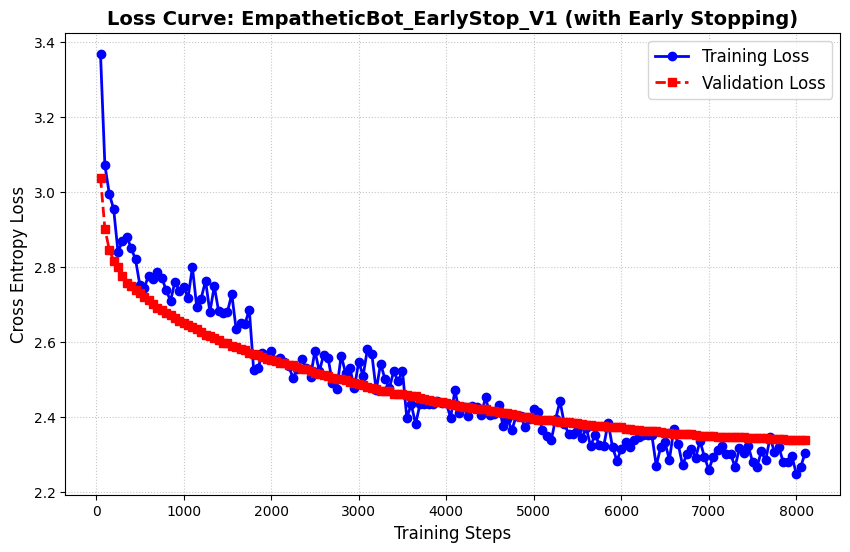

In [8]:
# GENERATING TRAINING VS VALIDATION GRAPH
import matplotlib.pyplot as plt

# 1. Extract logs
log_history = trainer.state.log_history

# 2. Separate the metrics
train_steps = [log['step'] for log in log_history if 'loss' in log]
train_losses = [log['loss'] for log in log_history if 'loss' in log]

eval_steps = [log['step'] for log in log_history if 'eval_loss' in log]
eval_losses = [log['eval_loss'] for log in log_history if 'eval_loss' in log]

# 3. Ploting the Graph
plt.figure(figsize=(10, 6))

plt.plot(train_steps, train_losses, marker='o', linestyle='-', color='blue', linewidth=2, label='Training Loss')
plt.plot(eval_steps, eval_losses, marker='s', linestyle='--', color='red', linewidth=2, label='Validation Loss')

# Format the chart
plt.title(f'Loss Curve: {custom_model_name} (with Early Stopping)', fontsize=14, fontweight='bold')
plt.xlabel('Training Steps', fontsize=12)
plt.ylabel('Cross Entropy Loss', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend(fontsize=12)

plt.show()

In [10]:
!pip install gradio -q

In [12]:
# FULL INTERACTIVE WEB APP WITH (NEW GRADIO)
import gradio as gr
from transformers import pipeline

# Load the model from your Google Drive
drive_folder = '/content/drive/MyDrive/Internship_Tasks/EmpatheticBot_EarlyStop_V1'
print("Loading Model into Web App...")
empathetic_pipe = pipeline("text-generation", model=drive_folder, tokenizer=drive_folder)

# Define the exact function the Web App will use to generate replies
def generate_response(message, history):
    # Format the input exactly as the model was trained
    prompt = f"User: {message}\nBot:"

    # Generate the text
    output = empathetic_pipe(
        prompt,
        max_length=150,
        do_sample=True,
        top_p=0.92,
        temperature=0.65,
        pad_token_id=empathetic_pipe.tokenizer.eos_token_id
    )

    # Clean the output
    full_text = output[0]['generated_text']
    bot_reply = full_text.split("Bot:")[-1].split("User:")[0].strip()

    return bot_reply

# 3. Build the Modern Chat Interface
demo = gr.ChatInterface(
    fn=generate_response,
    title="🧠 AI Empathetic Assistant",
    description="A fine-tuned mental health conversational agent built with DistilGPT2.",
    theme="soft",
    examples=["I'm feeling really stressed about my workload today.", "I just had a great day!", "I'm so tired and I don't know why."]
)

# 4. Launching the Web App
print("Starting Web Server...")
demo.launch(share=True, debug=False)

Loading Model into Web App...


Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/gradio/chat_interface.py:347: UserWarning: The 'tuples' format for chatbot messages is deprecated and will be removed in a future version of Gradio. Please set type='messages' instead, which uses openai-style 'role' and 'content' keys.
  self.chatbot = Chatbot(


Starting Web Server...
Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://8e87c5f67eef1681a3.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
